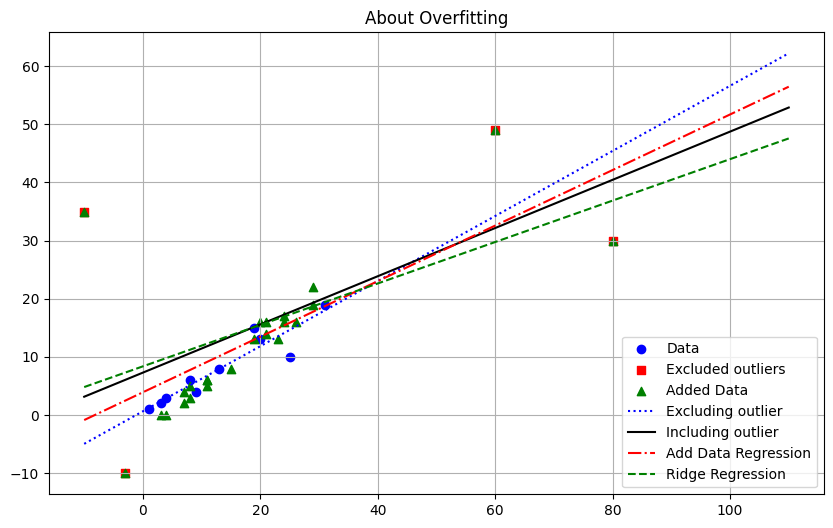

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
#from sklearn.linear_model import Lasso

# 임의의 데이터셋 생성
X = np.array([1, 3, 4, 9, 8, 13, 25, 19, 20, 31, 80, -10, 60, -3]).reshape(-1,1)  # 극단적 값 생성
y = np.array([1, 2, 3, 4, 6, 8, 28, 15, 20, 19, 30,35,49,-10])                

filtX=np.array([1, 3, 4, 9, 8, 13, 25, 19, 20, 31]).reshape(-1,1) #극단적 값 제거
filtY=np.array([1, 2, 3, 4, 6, 8, 10, 15, 13, 19])

addX = np.array([1, 3, 4, 9, 8, 13, 25, 19, 20, 31, 80, -10, 60, -3,
              7, 20, 29, 15, 11, 8, 29, 21, 7, 26, 19, 23, 11, 11, 24, 21, 4, 8, 24, 3]).reshape(-1,1)

addY = np.array([1, 2, 3, 4, 6, 8, 28, 15, 20, 19, 30, 35, 49, -10,
              2, 16, 22, 8, 5, 3, 19, 14, 4, 16, 13, 13, 6, 6, 16, 16, 0, 5, 17, 0])

#모델 학습
model = LinearRegression()
model.fit(X, y)

filtModel=LinearRegression()
filtModel.fit(filtX, filtY)

addModel=LinearRegression()
addModel.fit(addX,addY)

ridge_model = Ridge(alpha=1300)  # alpha 값이 클수록 모델 가중치 제한 커짐
ridge_model.fit(X, y)

#lasso_model=Lasso(alpha=10) alpha클수록 가중치 제한
#lasso_model.fit(X,y)


#x범위 설정
X_range = np.linspace(-10, 110, 200).reshape(-1,1)

#예측값 저장
y_full = model.predict(X_range)
y_filt = filtModel.predict(X_range)
y_add=addModel.predict(X_range)
y_ridge = ridge_model.predict(X_range)
#y_lasso = lasso_model.predict(X_range)

# 데이터 산점도 그리기
plt.figure(figsize=(10,6))
plt.scatter(filtX, filtY, color="blue", label="Data")

outlier_mask = (X.flatten() >= 40) | (X.flatten()<=0)
plt.scatter(X[outlier_mask], y[outlier_mask], color="red", marker="s", label="Excluded outliers")
plt.scatter(addX[10:], addY[10:], color="green", marker="^", label="Added Data")

#직선 그리기
plt.plot(X_range, y_filt, "b:", label="Excluding outlier")
plt.plot(X_range, y_full, "k", label="Including outlier")
plt.plot(X_range, y_add, "r-.", label="Add Data Regression")
plt.plot(X_range, y_ridge, "g--", label="Ridge Regression")
#plt.plot(X_range, y_lasso, "y--", label="Lasso Regression")


plt.title("About Overfitting")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

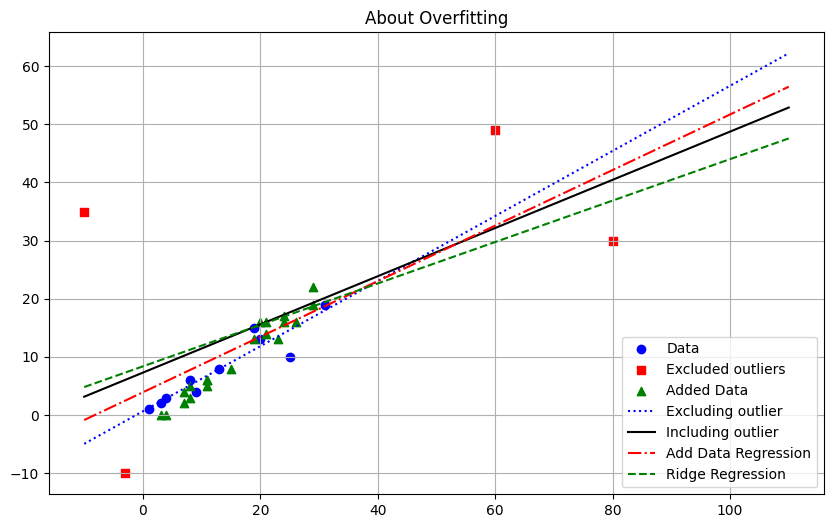

In [35]:
#필요 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
#from sklearn.linear_model import Lasso

# 임의의 데이터셋 생성
X = np.array([1, 3, 4, 9, 8, 13, 25, 19, 20, 31, 80, -10, 60, -3]).reshape(-1,1)  # 극단적 값 생성
y = np.array([1, 2, 3, 4, 6, 8, 28, 15, 20, 19, 30,35,49,-10])          

filtX=np.array([1, 3, 4, 9, 8, 13, 25, 19, 20, 31]).reshape(-1,1) #극단적 값 제거
filtY=np.array([1, 2, 3, 4, 6, 8, 10, 15, 13, 19])

#데이터 값 추가
addX = np.array([1, 3, 4, 9, 8, 13, 25, 19, 20, 31, 80, -10, 60, -3,
              7, 20, 29, 15, 11, 8, 29, 21, 7, 26, 19, 23, 11, 11, 24, 21, 4, 8, 24, 3]).reshape(-1,1)

addY = np.array([1, 2, 3, 4, 6, 8, 28, 15, 20, 19, 30, 35, 49, -10,
              2, 16, 22, 8, 5, 3, 19, 14, 4, 16, 13, 13, 6, 6, 16, 16, 0, 5, 17, 0])


#모델 학습
model = LinearRegression() #기존 데이터 선형회귀
model.fit(X, y)

filtModel=LinearRegression() #이상치 제거 선형회귀
filtModel.fit(filtX, filtY)


addModel=LinearRegression() #데이터값 추가 선형회귀
addModel.fit(addX,addY)

#모델 가중치 변경해 과적합 방지하는 방법
#Ridge 회귀(L2 규제)
ridge_model = Ridge(alpha=1300)  # alpha 값이 클수록 모델 가중치 제한 커짐
#1300은 매우 큰 값이나 데이터가 적기 때문에 영향을 눈으로 보기 위한 과도한값
ridge_model.fit(X, y)

#lasso 회귀 (L1 규제)
#lasso_model=Lasso(alpha=10) alpha클수록 가중치 제한
#lasso_model.fit(X,y)

#ridge, lasso 회귀에 대한 설명
#https://seollane22.tistory.com/10
#단, 모델의 가중치를 변경하는 경우에는 과소적합이 발생할 수 있음에 유의해야한다.


#x범위 설정
X_range = np.linspace(-10, 110, 200).reshape(-1,1)

#예측값 저장
y_full = model.predict(X_range)  #기존 데이터 선형회귀 예측 값
y_filt = filtModel.predict(X_range) #이상치 제거 데이터 선형회귀 예측 값
y_add=addModel.predict(X_range) #데이터값 추가 선형회귀 예측 값
y_ridge = ridge_model.predict(X_range) #가중치 변경 릿지 회귀 예측 값
#y_lasso = lasso_model.predict(X_range) #가중치 변경 랏소 회귀 예측 값

# 데이터 산점도 그리기
plt.figure(figsize=(10,6)) #그래프 사이즈 제한
plt.scatter(filtX, filtY, color="blue", label="Data") #이상치 제거 데이터 산점도 그리기

outlier_mask = (X.flatten() >= 40) | (X.flatten()<=0)#이상치 필터
plt.scatter(X[outlier_mask], y[outlier_mask], color="red", marker="s", label="Excluded outliers") #이상치 적색 사각형 표시

plt.scatter(addX[14:], addY[14:], color="green", marker="^", label="Added Data") #추가한 데이터만 표시(임의)

#직선 그리기
#저장된 y 예측값을 가지고 회귀선 그리기
plt.plot(X_range, y_filt, "b:", label="Excluding outlier")
plt.plot(X_range, y_full, "k", label="Including outlier")
plt.plot(X_range, y_add, "r-.", label="Add Data Regression")
plt.plot(X_range, y_ridge, "g--", label="Ridge Regression")
#plt.plot(X_range, y_lasso, "y--", label="Lasso Regression")


plt.title("About Overfitting")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()